In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report
)

In [2]:
X_train = pd.read_csv("../data/X_train.csv")
X_val = pd.read_csv("../data/X_val.csv")
y_val = pd.read_csv("../data/y_val.csv").values.ravel()
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").values.ravel()

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
fitted_models = {name: joblib.load(f"../models/{name.replace(' ', '_').lower()}.joblib") for name in model_names}

best_model_name = joblib.load("../models/best_model_name.joblib")
best_model = fitted_models[best_model_name]

y_test_pred = np.load("../data/y_test_pred.npy", allow_pickle=True)
y_test_proba = np.load("../data/y_test_proba.npy", allow_pickle=True)

os.makedirs("../plots", exist_ok=True)
print(f"Loaded 4 models. Final selected model: {best_model_name}")

Loaded 4 models. Final selected model: Gradient Boosting


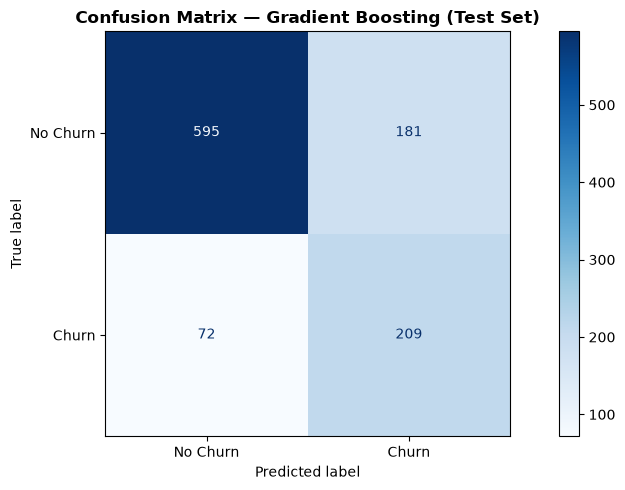

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name} (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/05_confusion_matrix.png')
plt.show()

In [5]:
print(f"--- Classification Report: {best_model_name} (Test Set) ---")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

--- Classification Report: Gradient Boosting (Test Set) ---
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82       776
       Churn       0.54      0.74      0.62       281

    accuracy                           0.76      1057
   macro avg       0.71      0.76      0.72      1057
weighted avg       0.80      0.76      0.77      1057



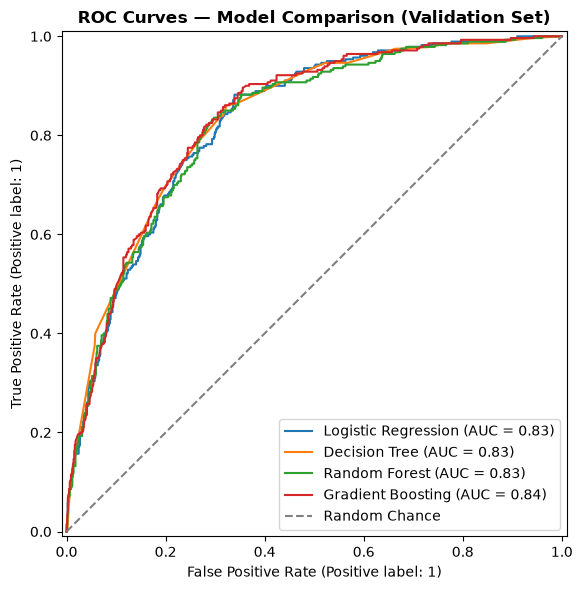

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
ax.set_title('ROC Curves — Model Comparison (Validation Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/06_roc_curves.png')
plt.show()

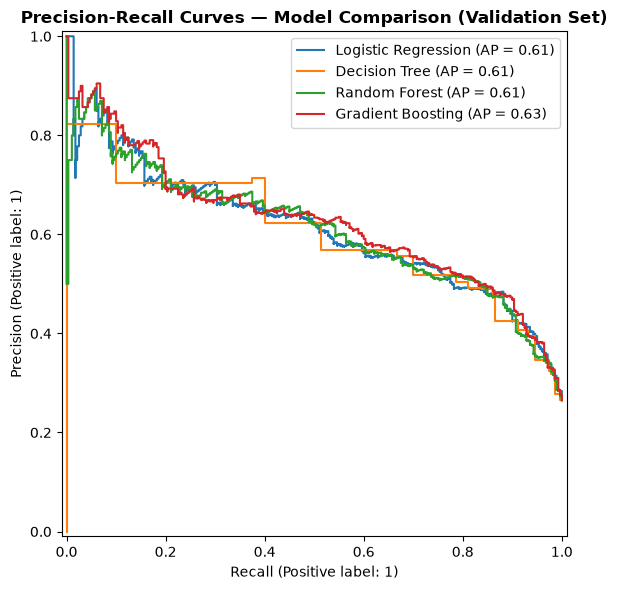

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, model in fitted_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.set_title('Precision-Recall Curves — Model Comparison (Validation Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/07_pr_curves.png')
plt.show()

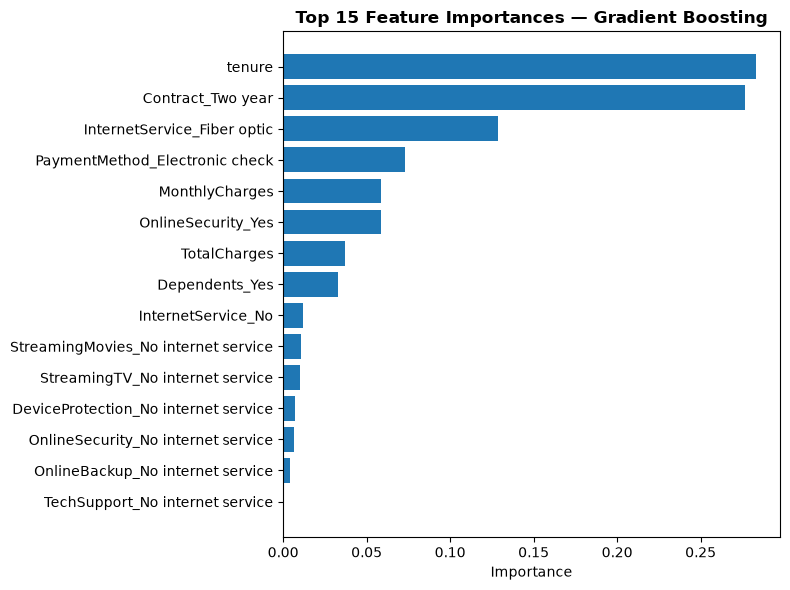

In [8]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
elif hasattr(best_model, 'coef_'):
    importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': np.abs(best_model.coef_[0])
    }).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'][:15][::-1], importances['Importance'][:15][::-1], color='#1f77b4')
plt.title(f'Top 15 Feature Importances — {best_model_name}', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../plots/08_feature_importance.png')
plt.show()

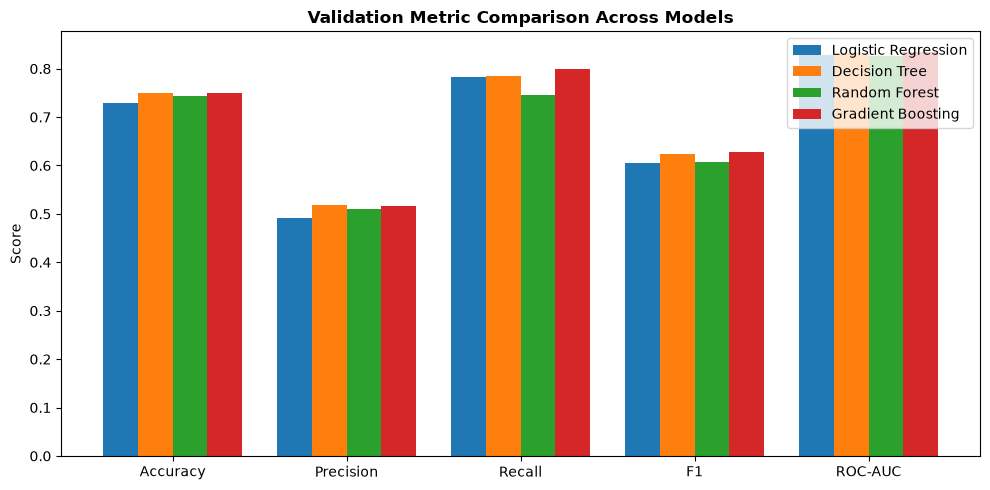

In [9]:
val_df = pd.read_csv("../data/model_results.csv")

metrics = ['Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1', 'Val_ROC_AUC']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(model_names):
    row = val_df[val_df['Model'] == name]
    if row.empty:
        continue
    values = [row[m].values[0] for m in metrics]
    ax.bar(x + i * width, values, width, label=name)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
ax.set_ylabel('Score')
ax.set_title('Validation Metric Comparison Across Models', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/09_model_comparison.png')
plt.show()

## Interpretation of Results

**Model selection:** {best_model_name} was selected as the final model based on the
highest F1 score on the validation set, prioritizing F1/ROC-AUC over raw accuracy
because the original churn distribution is imbalanced (~73% No / 27% Yes) — a model
that just predicts "No Churn" for everyone would already score ~73% accuracy while
being useless.

**Key churn drivers:** [fill in from the feature importance plot — e.g. tenure,
Contract_Month-to-month, MonthlyCharges typically dominate on this dataset]

**Confusion matrix trade-off:** False negatives (predicted "No Churn" but customer
actually churned) are the costlier error for a telecom business — each one is a
customer lost without any retention intervention. False positives (predicted churn
but customer stays) just cost an unnecessary retention offer. [state your model's
actual FN/FP counts here and comment on whether recall on the churn class is
strong enough for this to be useful in practice]

**Business recommendation:** [e.g. target retention campaigns at month-to-month
contract customers in their first 12 months with high monthly charges — tie back
to your feature importance findings]